In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Moham\Desktop\Projects\predicting-digital-distraction-impact\student_digital_life(First_data).csv")
df

,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2,Good,Masters,Average,6.32,82.70
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3,Average,Masters,Poor,2.52,85.65
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2,Good,HighSchool,Poor,3.98,88.14
3,4,20,Female,0.00,1.15,1.32,4.19,0.27,7.86,0.18,84.41,79.07,0,Average,HighSchool,Average,4.77,54.81
4,5,24,Male,7.23,1.39,2.21,4.67,2.75,7.88,0.28,81.13,65.40,4,Good,HighSchool,Average,8.77,84.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,22,Female,4.40,5.47,0.00,2.10,1.45,8.26,0.05,88.61,73.31,1,Poor,Masters,Average,6.06,66.39
14996,14997,24,Male,6.21,11.89,3.98,3.92,3.83,7.07,0.00,80.00,73.04,0,Poor,Bachelors,Average,10.00,73.38
14997,14998,21,Male,6.61,5.82,2.33,1.33,2.01,3.91,1.67,80.68,90.72,1,Poor,Bachelors,Average,10.00,98.00
14998,14999,22,Female,3.67,4.58,2.51,4.54,3.80,8.35,1.67,81.76,48.75,1,Good,HighSchool,Average,6.22,68.07


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     15000 non-null  int64  
 1   age                            15000 non-null  int64  
 2   gender                         15000 non-null  str    
 3   study_hours_per_day            15000 non-null  float64
 4   smartphone_usage_hours         15000 non-null  float64
 5   social_media_hours             15000 non-null  float64
 6   gaming_hours                   15000 non-null  float64
 7   streaming_hours                15000 non-null  float64
 8   sleep_hours                    15000 non-null  float64
 9   exercise_hours                 15000 non-null  float64
 10  class_attendance_percent       15000 non-null  float64
 11  assignment_completion_percent  15000 non-null  float64
 12  caffeine_intake_cups           15000 non-null  int64  
 1

In [4]:
df.describe()

,student_id,age,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,motivation_level,final_exam_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,21.024400,4.511505,5.503475,3.516837,2.241304,1.829245,6.997377,1.234827,84.631745,79.445435,1.504933,5.988216,80.344360
std,4330.271354,2.594299,1.981043,2.437488,1.767000,1.468125,1.132042,1.456868,0.827273,9.452752,13.918023,1.227060,1.949031,18.434455
min,1.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.500000,0.000000,44.960000,30.000000,0.000000,1.000000,2.630000
25%,3750.750000,19.000000,3.167500,3.830000,2.280000,1.110000,0.990000,5.970000,0.600000,78.180000,70.007500,1.000000,4.650000,68.730000
50%,7500.500000,21.000000,4.510000,5.480000,3.490000,2.175000,1.780000,6.990000,1.190000,84.895000,80.220000,1.000000,6.000000,83.745000
75%,11250.250000,23.000000,5.840000,7.150000,4.710000,3.260000,2.600000,8.030000,1.800000,91.650000,90.275000,2.000000,7.340000,97.810000
max,15000.000000,25.000000,11.780000,14.000000,9.000000,8.000000,6.000000,10.000000,4.660000,100.000000,100.000000,8.000000,10.000000,100.000000


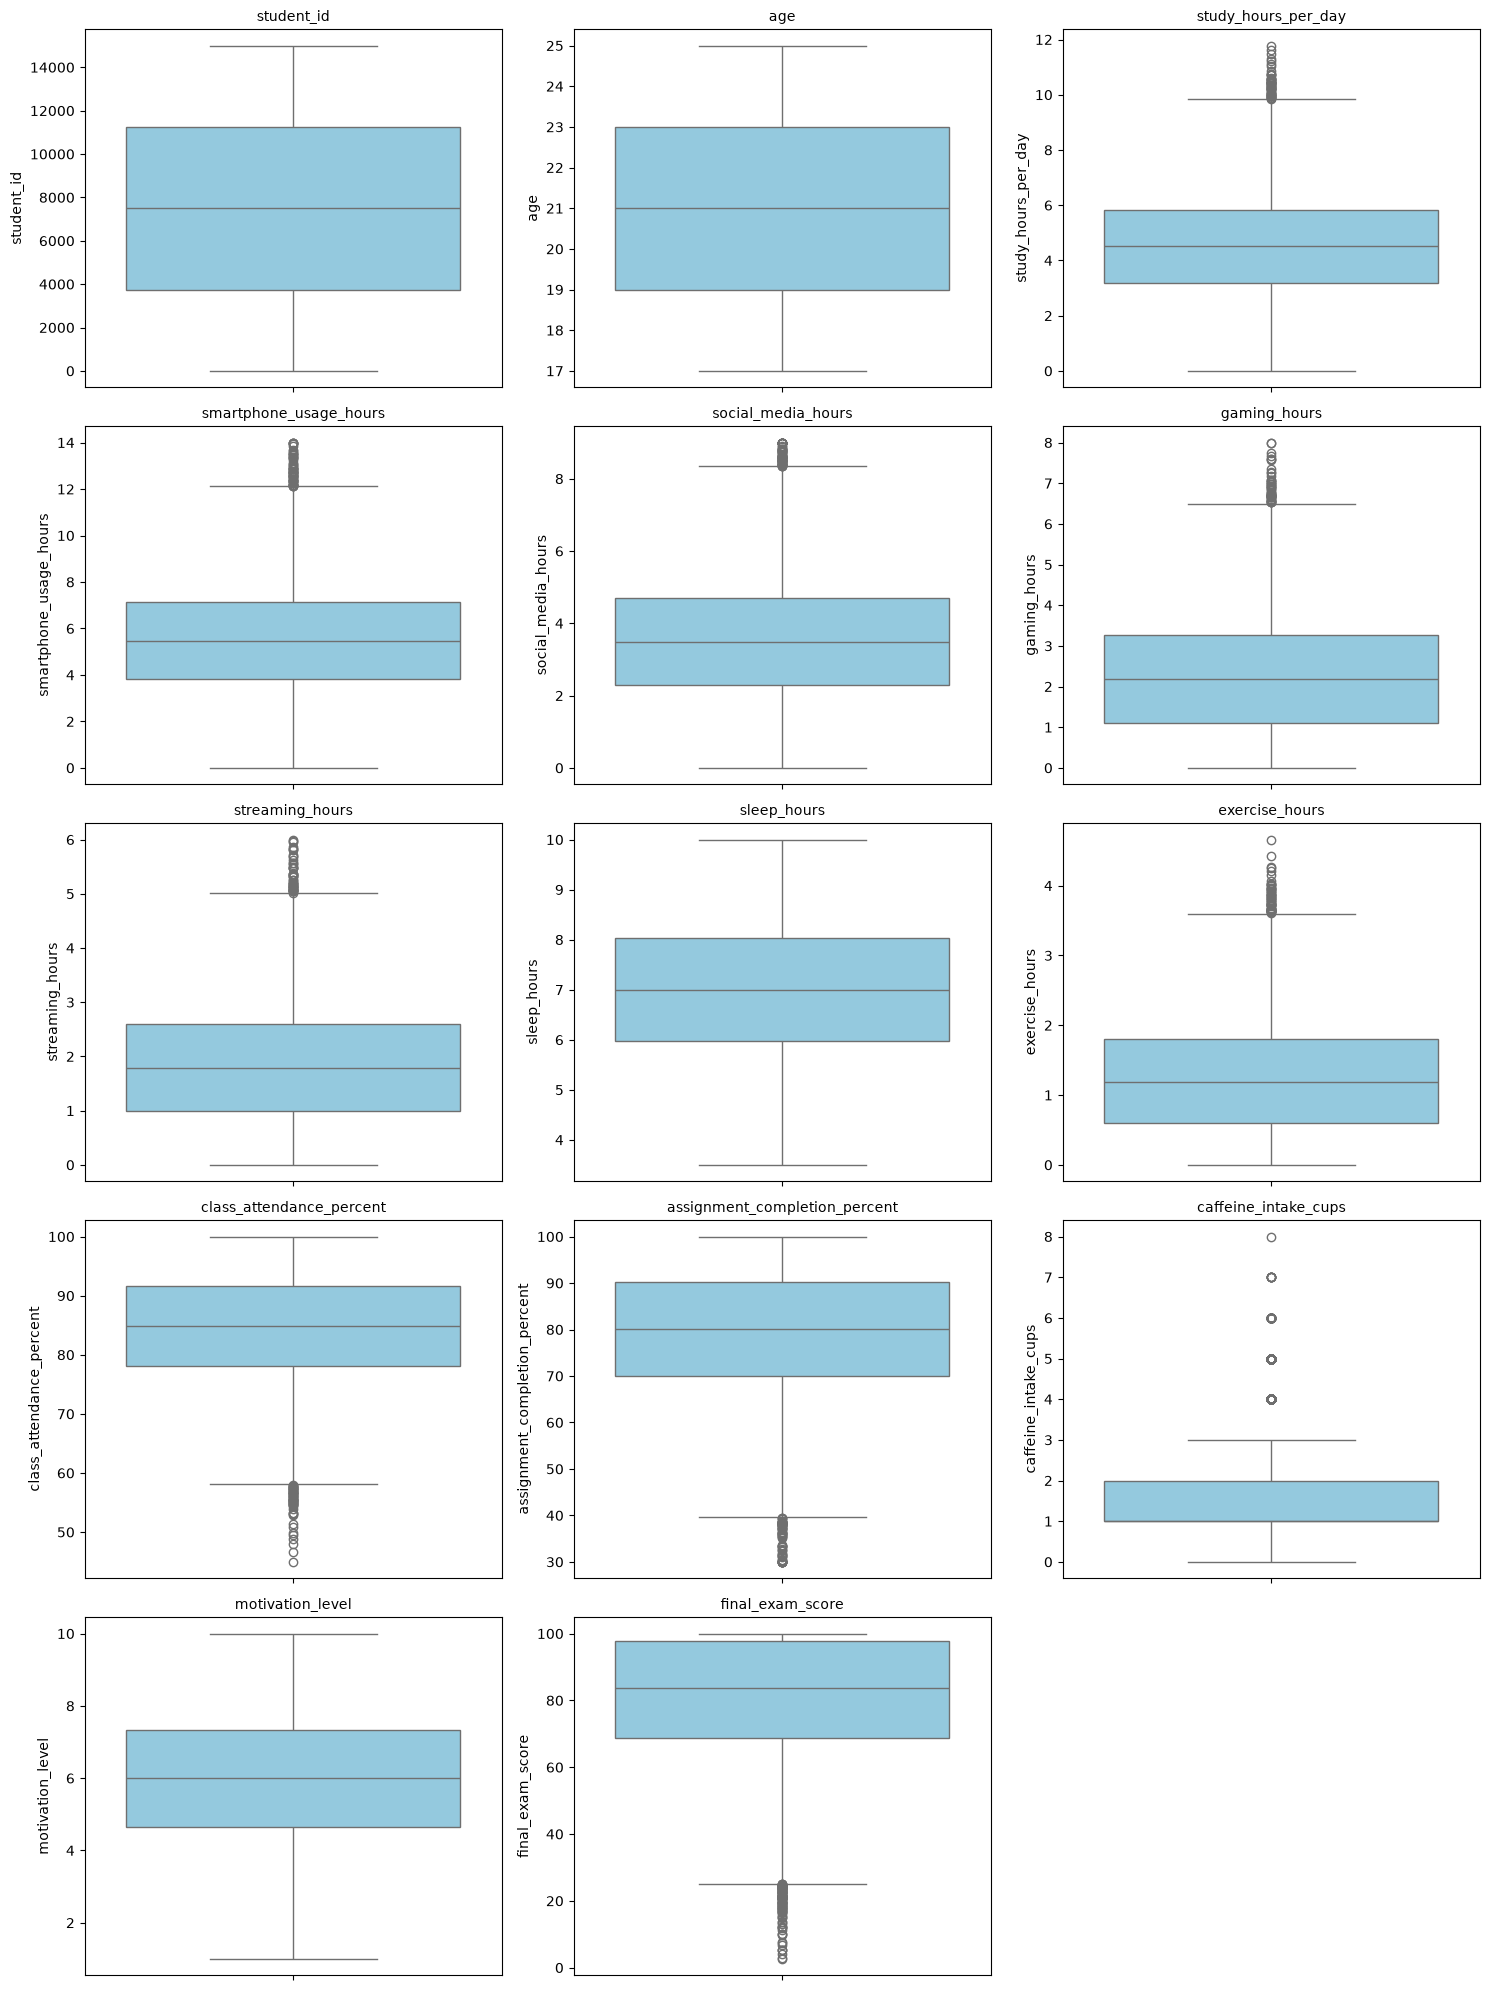

In [5]:
import math

num_col = df.select_dtypes(include = ["number"]).columns
col_n = 3
row_n = math.ceil(len(num_col) / col_n )
fig , axes = plt.subplots(row_n , col_n , figsize = (15, row_n *4))
axes = axes.flatten()

for i , col in enumerate(num_col) :
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [6]:
has_outliers = ['study_hours_per_day' , 'smartphone_usage_hours' , 'social_media_hours', 'gaming_hours','streaming_hours','exercise_hours','caffeine_intake_cups','final_exam_score','class_attendance_percent','assignment_completion_percent']



for  col in has_outliers :
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

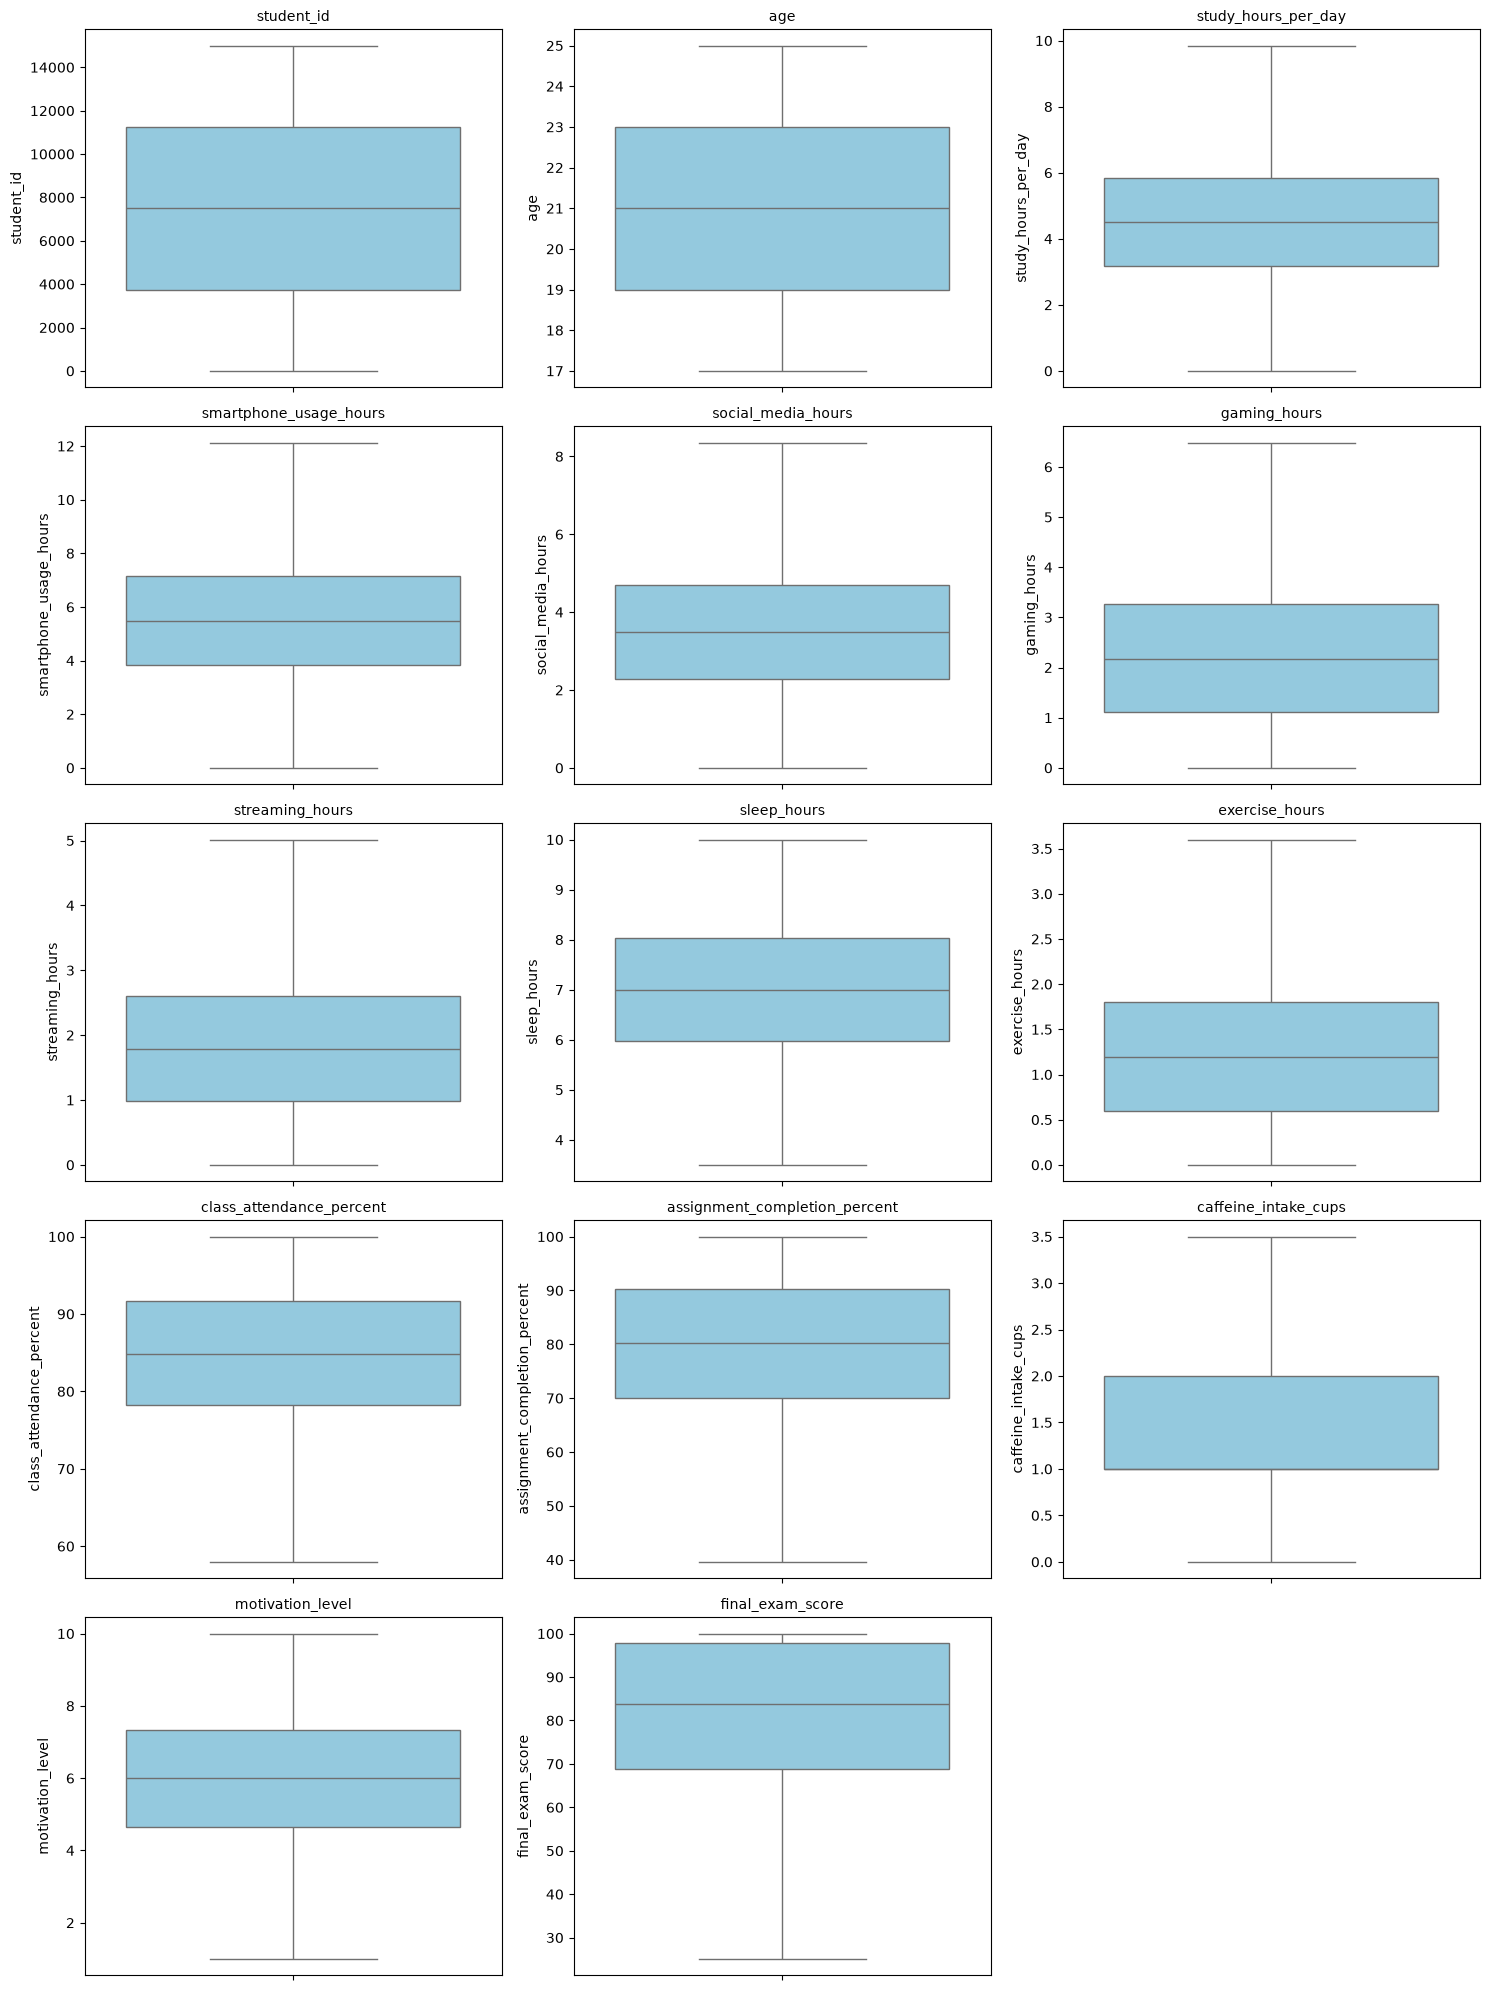

In [7]:
import math

num_col = df.select_dtypes(include = ["number"]).columns
col_n = 3
row_n = math.ceil(len(num_col) / col_n )
fig , axes = plt.subplots(row_n , col_n , figsize = (15, row_n *4))
axes = axes.flatten()

for i , col in enumerate(num_col) :
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

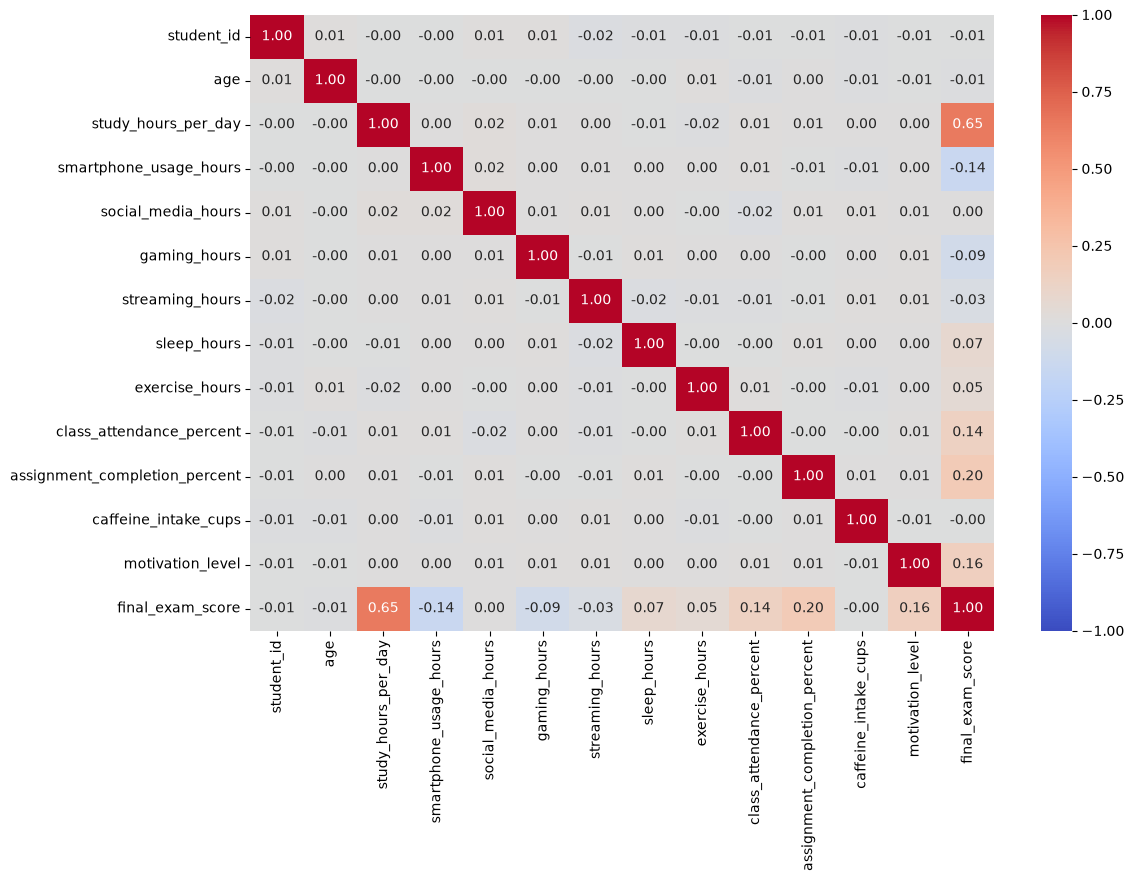

In [8]:
num_col = df.select_dtypes(include = ['number'])

correlation = num_col.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(correlation, annot=True, cmap='coolwarm' , vmin = -1 , vmax = 1 , fmt ="0.02f")
plt.show()

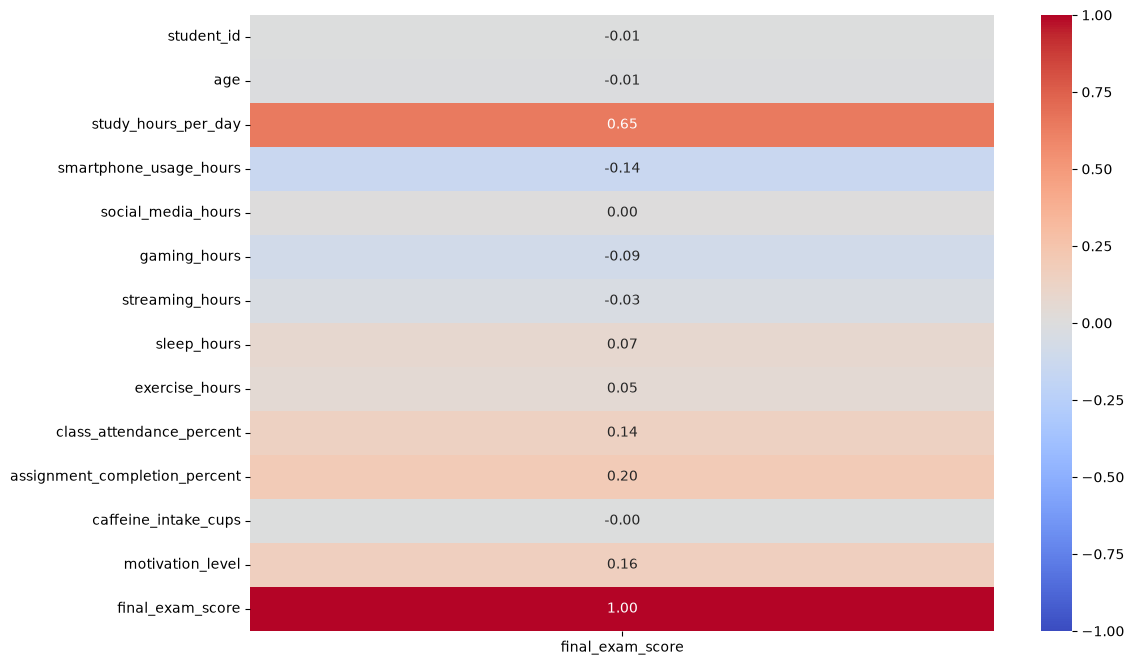

In [9]:
num_col = df.select_dtypes(include = ['number'])

correlation = num_col.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(correlation[["final_exam_score"]], annot=True, cmap='coolwarm' , vmin = -1 , vmax = 1 , fmt ="0.02f")
plt.show()

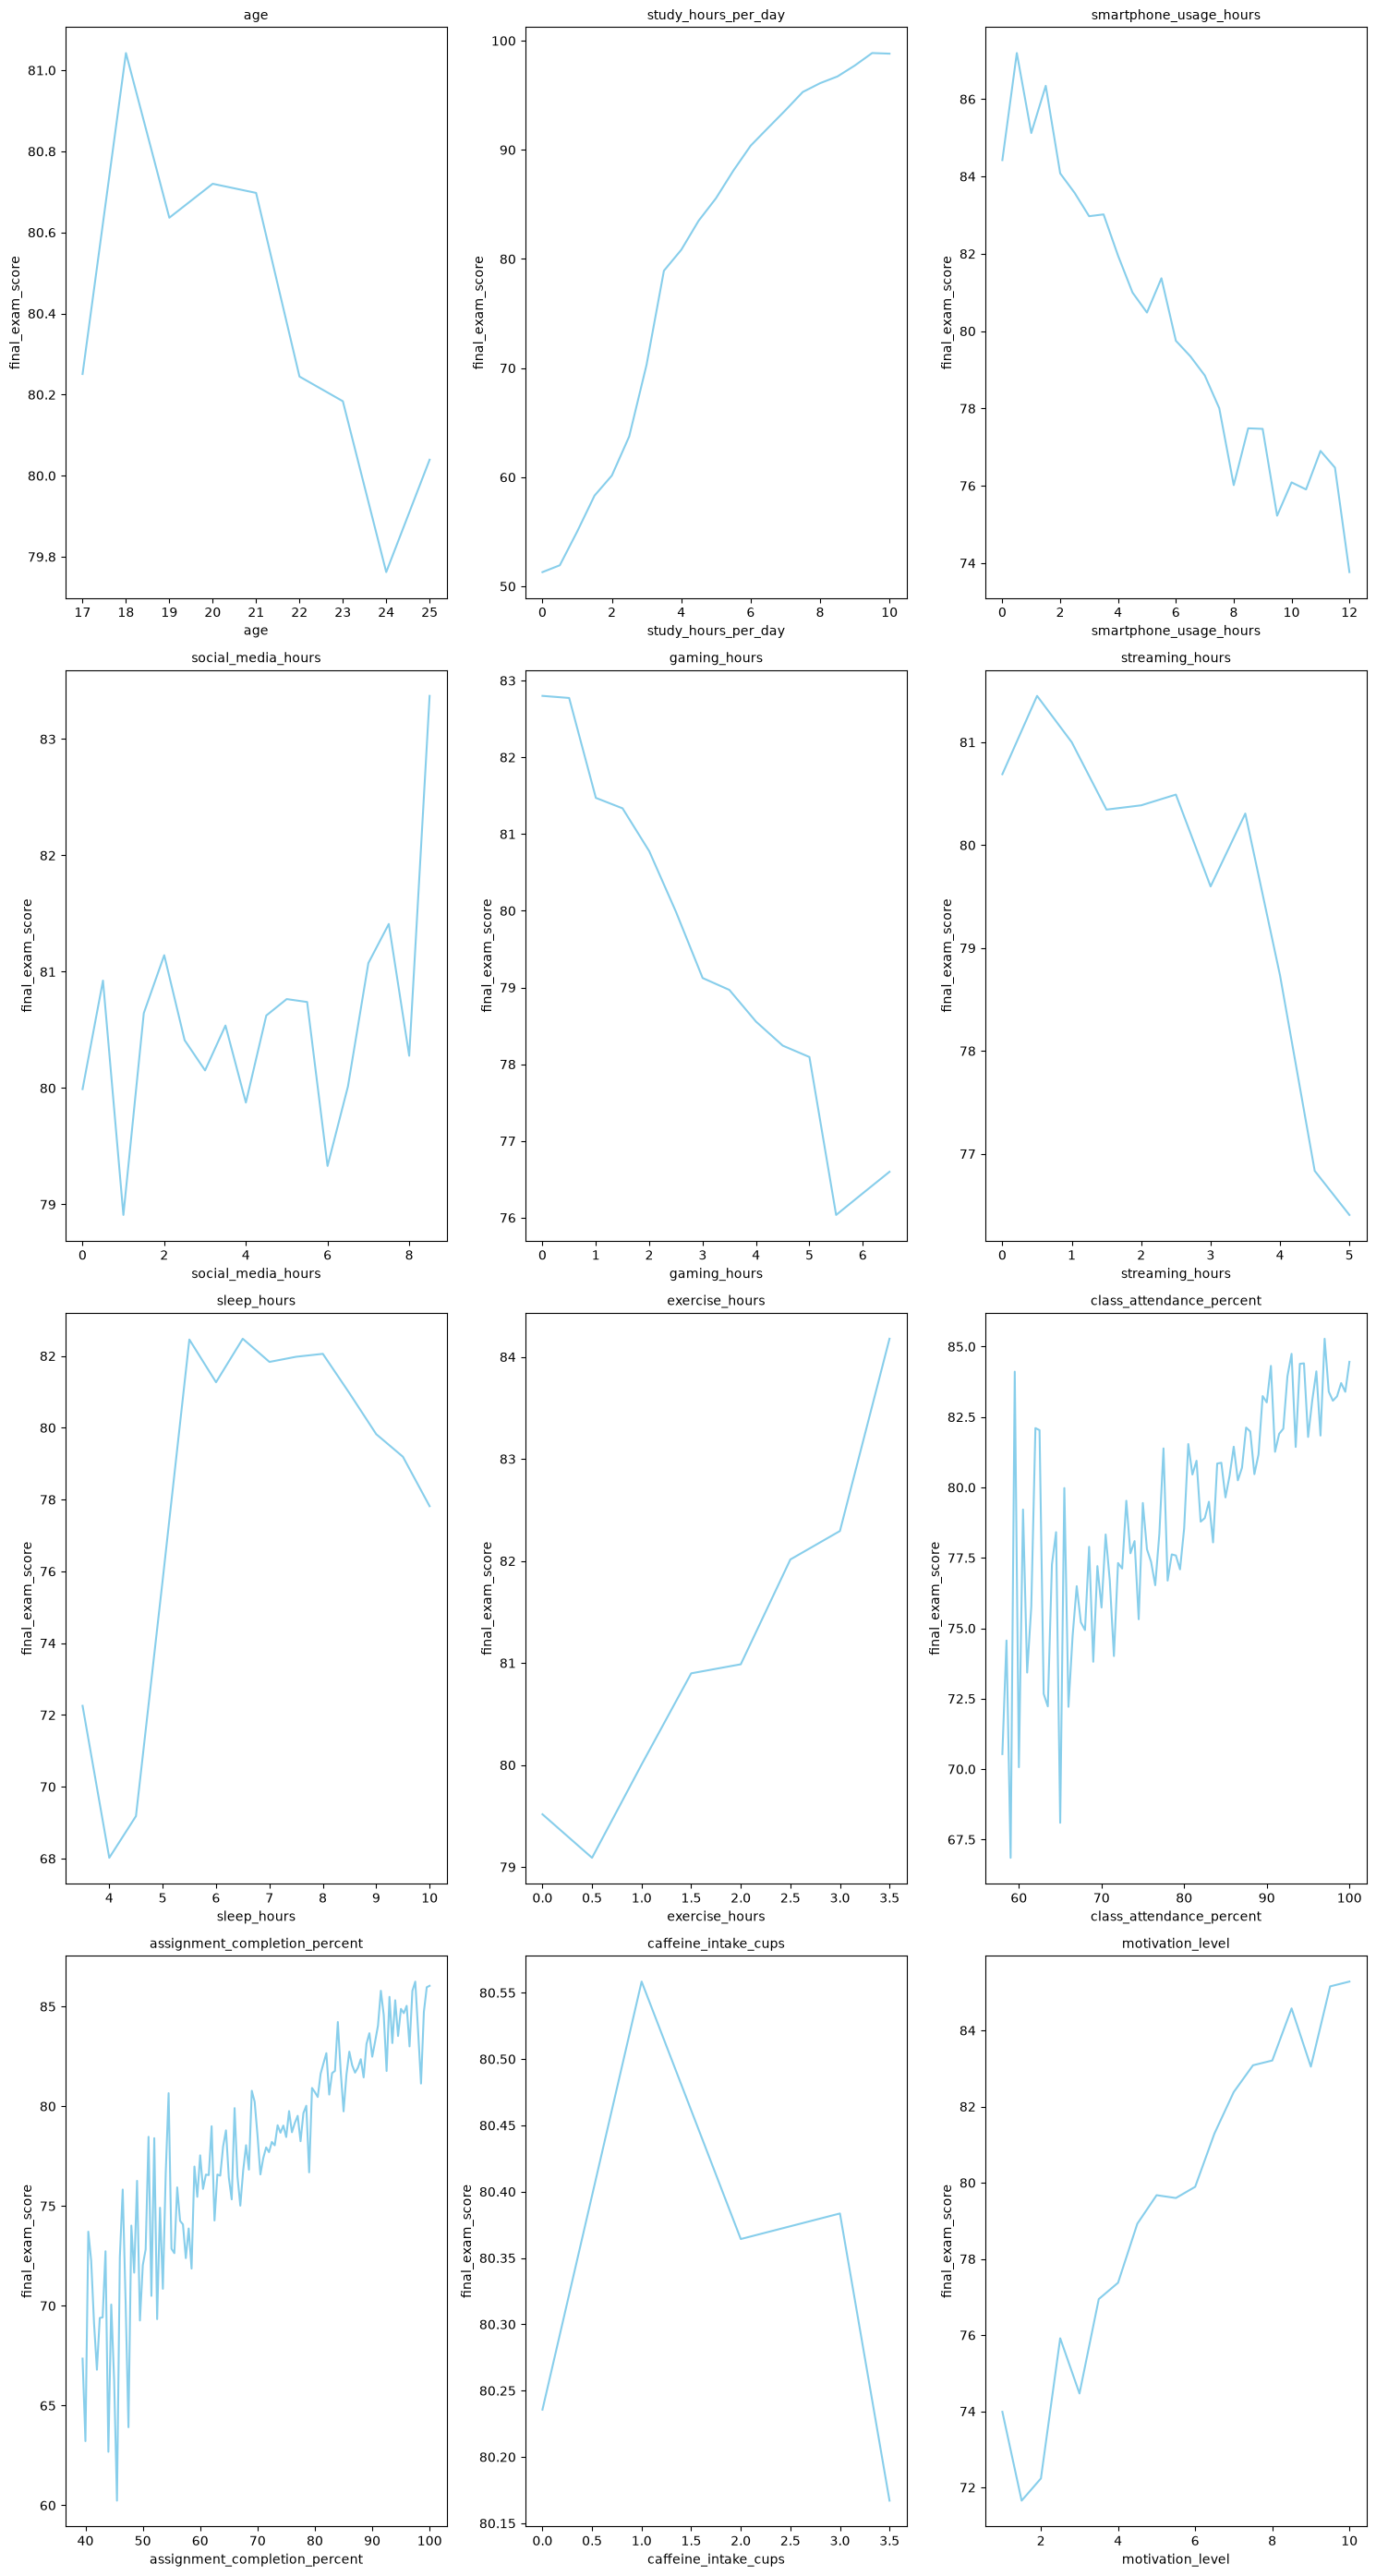

In [10]:
import math

num_col = df.select_dtypes(include = ["number"]).columns.drop(['student_id','final_exam_score'])
col_n = 3
row_n = math.ceil(len(num_col) / col_n )
fig , axes = plt.subplots(row_n , col_n , figsize = (15, row_n *7))
axes = axes.flatten()

for i , col in enumerate(num_col) :
    rounded_col = (df[col]*2).round() / 2
    grouped_data = df.groupby(rounded_col)['final_exam_score'].mean().reset_index()
    sns.lineplot(data=grouped_data, x=col, y="final_exam_score", ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

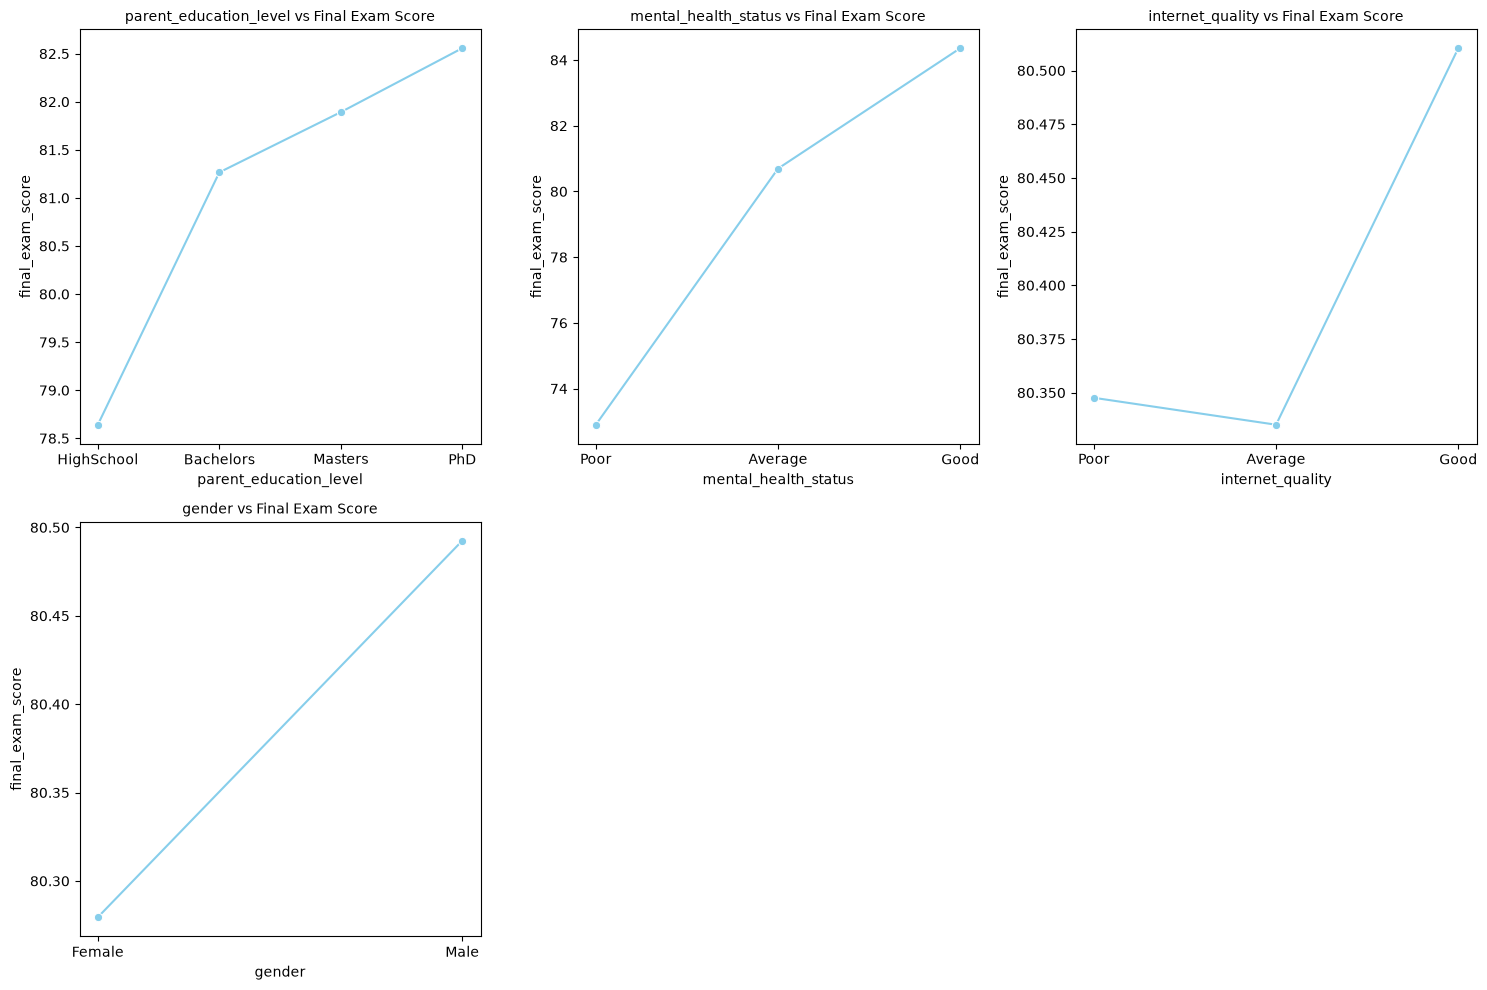

In [11]:

custom_orders = {
    'parent_education_level': ['HighSchool', 'Bachelors', 'Masters', 'PhD'],
    'mental_health_status': ['Poor', 'Average', 'Good'],
    'internet_quality': ['Poor', 'Average', 'Good'],
    'gender': ['Female', 'Male']
}

cat_cols = list(custom_orders.keys())

col_n = 3
row_n = math.ceil(len(cat_cols) / col_n)

fig, axes = plt.subplots(row_n, col_n, figsize=(15, row_n * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    grouped_data = df.groupby(col)['final_exam_score'].mean().reset_index()
    
    order = custom_orders[col]
    grouped_data[col] = pd.Categorical(grouped_data[col], categories=order, ordered=True)
    grouped_data = grouped_data.sort_values(col)

    sns.lineplot(
        data=grouped_data, 
        x=col, 
        y="final_exam_score", 
        ax=axes[i], 
        color='skyblue',
        marker='o' 
    )
    
    axes[i].set_title(f"{col} vs Final Exam Score", fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [12]:
import plotly.express as px

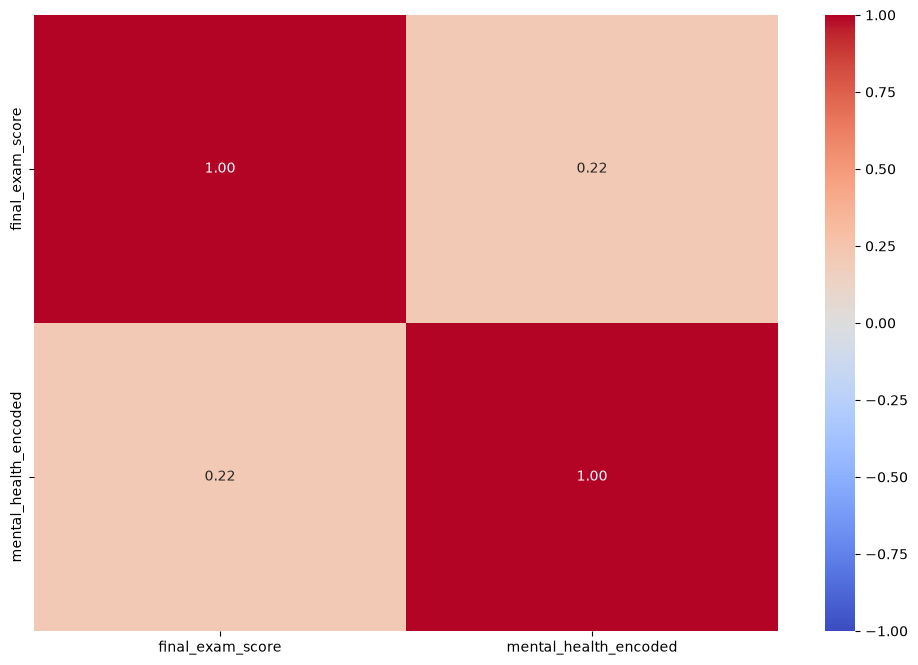

In [13]:
mapping = {'Poor': 0, 'Average': 1, 'Good': 2}

df['mental_health_encoded'] = df['mental_health_status'].map(mapping)

correlation = df[['final_exam_score', 'mental_health_encoded']].corr()
plt.figure(figsize=(12, 8))

sns.heatmap(correlation, annot=True, cmap='coolwarm' , vmin = -1 , vmax = 1 , fmt ="0.02f")
plt.show()


In [14]:
grouped_data = df.groupby('mental_health_status')['final_exam_score'].mean().reset_index()

order = ['Poor', 'Average', 'Good']

fig = px.bar(grouped_data, x='mental_health_status', y="final_exam_score",category_orders={'mental_health_status': order},  color='mental_health_status',  text_auto='.2f',title="Average Final Exam Score by Mental Health Status"
    ,labels={'mental_health_status': 'Mental Health Status','final_exam_score': 'Average Final Exam Score'})
    
    

fig.update_layout(showlegend=False)
fig.update_traces(textposition='outside')

fig.show()

In [15]:
data = df[["final_exam_score","study_hours_per_day"]]
fig = px.scatter(data, x='study_hours_per_day', y="final_exam_score" , trendline="ols" ,trendline_color_override="red",title="Regression Line: Study Hours per day VS Final Exam Score")

fig.show()

# Predict Final exam score on another dataset (المعيار هو الداتا الإصطناعية الأولي)
### First Clean the data

In [16]:
dff = pd.read_csv(r"C:\Users\Moham\Desktop\Projects\predicting-digital-distraction-impact\predict_student_performance(Second_data).csv")
dff

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,Kenneth Murray,Male,85.0,20.0,NaN,1.0,High,72.0,0.8,80.0,True
996,4497.0,Amy Stout,Female,91.0,NaN,86.0,0.0,High,90.0,3.9,80.0,True
997,1886.0,NaN,Male,85.0,8.0,82.0,2.0,Low,68.0,0.4,54.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,0.9,53.0,True


In [17]:
dff.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    str    
 2   Gender                     952 non-null    str    
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    str    
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(1), str(3)
memory usage: 93.9+ KB


In [18]:
dff.sort_values(ascending=True , by="StudentID")

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
918,NaN,Matthew Winters,Male,78.0,30.0,60.0,0.0,Medium,72.0,2.8,75.0,False
975,NaN,Nancy Gibson,Female,78.0,12.0,82.0,1.0,Medium,90.0,2.2,91.0,True
978,NaN,Nina Fowler,Male,70.0,22.0,78.0,3.0,Medium,68.0,4.1,85.0,True
992,NaN,James Garcia,Male,91.0,15.0,90.0,2.0,High,68.0,4.3,68.0,False


In [19]:
dff.head(20)

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True
5,6.0,Olivia,Female,95.0,30.0,88.0,1.0,High,NaN,2.8,97.0,False
6,7.0,Daniel,Male,70.0,8.0,60.0,0.0,Low,62.0,4.5,96.0,False
7,8.0,Sophia,Female,NaN,17.0,77.0,1.0,Medium,78.0,1.0,70.0,True
8,9.0,James,Male,82.0,12.0,70.0,2.0,Low,72.0,3.6,50.0,False
9,10.0,Isabella,Female,91.0,22.0,86.0,3.0,High,88.0,2.9,59.0,True


In [20]:
dff[dff['StudentID'].isna()]

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
14,NaN,James Williams,Male,70.0,20.0,70.0,2.0,Low,88.0,4.4,73.0,True
16,NaN,Courtney Clark,NaN,95.0,25.0,82.0,2.0,Low,68.0,2.7,65.0,True
37,NaN,Christopher Chapman,Male,95.0,25.0,82.0,0.0,High,85.0,2.3,98.0,True
99,NaN,Natalie Kelley,Male,92.0,22.0,60.0,3.0,Medium,80.0,1.6,80.0,False
127,NaN,Tina Chavez,NaN,70.0,20.0,88.0,0.0,Medium,85.0,1.9,59.0,False
170,NaN,Jasmine Williams,Male,95.0,18.0,85.0,1.0,Medium,62.0,3.7,74.0,False
192,NaN,Jonathan Hodges,Female,92.0,25.0,86.0,1.0,High,80.0,1.4,88.0,False
195,NaN,Shirley Jackson,Male,78.0,20.0,60.0,1.0,Medium,72.0,4.7,98.0,True
214,NaN,Kristi Cross,Male,85.0,18.0,60.0,3.0,Medium,85.0,4.8,69.0,True
221,NaN,Steven Wood,Male,70.0,30.0,85.0,2.0,High,NaN,4.9,80.0,True


In [21]:
max_value = int(dff['StudentID'].max())
null_musk = dff['StudentID'].isna()
dff.loc[null_musk , 'StudentID'] = range(max_value +1 , max_value +1 + null_musk.sum())

In [22]:
dff['StudentID'].isna().sum()

np.int64(0)

In [23]:
dff.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  1000 non-null   float64
 1   Name                       966 non-null    str    
 2   Gender                     952 non-null    str    
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    str    
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(1), str(3)
memory usage: 93.9+ KB


In [24]:
dff[dff['Gender'].isna()]['Name'].unique().tolist()

['Courtney Clark',
 'Kristina Douglas',
 'Alyssa Schmidt',
 'Alyssa Smith',
 'Emily Torres',
 'Nancy Davis',
 'James Anderson',
 'Angela Williams',
 'Tina Chavez',
 'Jeffrey Meyers',
 'Paul Hickman',
 'Jose Liu',
 'Lynn Jennings',
 'Andrea Newman',
 nan,
 'Maurice Martinez',
 'Jonathon Perry',
 'Dennis Elliott',
 'Nancy Moore',
 'Heather Gamble',
 'Sarah Russell',
 'Pamela Woods',
 'Ronald Davis',
 'Marissa Raymond',
 'David Stone',
 'Ryan Vasquez',
 'Alicia Young',
 'Christopher Sullivan',
 'Lisa Williams',
 'Taylor Moyer',
 'Kathy Bailey',
 'Kenneth Jones',
 'David Cummings',
 'Drew Morse',
 'Tamara Jones',
 'Kimberly Harrison',
 'Justin Castro',
 'Richard Howard Jr.',
 'Andrew Schroeder',
 'Tom Bradley',
 'Isaiah Moore',
 'Jonathan Ramirez',
 'Jeff Carney',
 'Darlene Burton',
 'Emily Martin',
 'Joy Henderson',
 'Jaime Simon',
 'Rebecca Burnett']

In [25]:
gender_map = {
    'Courtney Clark': 'Female',
    'Kristina Douglas': 'Female',
    'Alyssa Schmidt': 'Female',
    'Alyssa Smith': 'Female',
    'Emily Torres': 'Female',
    'Nancy Davis': 'Female',
    'James Anderson': 'Male',
    'Angela Williams': 'Female',
    'Tina Chavez': 'Female',
    'Jeffrey Meyers': 'Male',
    'Paul Hickman': 'Male',
    'Jose Liu': 'Male',
    'Lynn Jennings': 'Female',
    'Andrea Newman': 'Female',
    'Maurice Martinez': 'Male',
    'Jonathon Perry': 'Male',
    'Dennis Elliott': 'Male',
    'Nancy Moore': 'Female',
    'Heather Gamble': 'Female',
    'Sarah Russell': 'Female',
    'Pamela Woods': 'Female',
    'Ronald Davis': 'Male',
    'Marissa Raymond': 'Female',
    'David Stone': 'Male',
    'Ryan Vasquez': 'Male',
    'Alicia Young': 'Female',
    'Christopher Sullivan': 'Male',
    'Lisa Williams': 'Female',
    'Taylor Moyer': 'Female',
    'Kathy Bailey': 'Female',
    'Kenneth Jones': 'Male',
    'David Cummings': 'Male',
    'Drew Morse': 'Male',
    'Tamara Jones': 'Female',
    'Kimberly Harrison': 'Female',
    'Justin Castro': 'Male',
    'Richard Howard Jr.': 'Male',
    'Andrew Schroeder': 'Male',
    'Tom Bradley': 'Male',
    'Isaiah Moore': 'Male',
    'Jonathan Ramirez': 'Male',
    'Jeff Carney': 'Male',
    'Darlene Burton': 'Female',
    'Emily Martin': 'Female',
    'Joy Henderson': 'Female',
    'Jaime Simon': 'Male',
    'Rebecca Burnett': 'Female'
}


dff['Gender'] = dff['Gender'].fillna(dff['Name'].map(gender_map))

In [26]:
dff['Gender'] = dff['Gender'].fillna('Unknown')

In [27]:
dff['Name'] = dff['Name'].fillna('Unknown')

In [28]:
dff.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  1000 non-null   float64
 1   Name                       1000 non-null   str    
 2   Gender                     1000 non-null   str    
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    str    
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(1), str(3)
memory usage: 93.9+ KB


In [29]:
dff.drop(['Study Hours' , 'Attendance (%)'],axis=1 , inplace=True)

In [30]:
dff

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,True
...,...,...,...,...,...,...,...,...,...,...
995,10038.0,Kenneth Murray,Male,85.0,20.0,NaN,1.0,High,72.0,True
996,4497.0,Amy Stout,Female,91.0,NaN,86.0,0.0,High,90.0,True
997,1886.0,Unknown,Male,85.0,8.0,82.0,2.0,Low,68.0,False
998,7636.0,Joseph Sherman,Male,88.0,17.0,60.0,2.0,High,85.0,True


In [31]:
dff.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  1000 non-null   float64
 1   Name                       1000 non-null   str    
 2   Gender                     1000 non-null   str    
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    str    
 8   FinalGrade                 960 non-null    float64
 9   Online Classes Taken       975 non-null    object 
dtypes: float64(6), object(1), str(3)
memory usage: 78.3+ KB


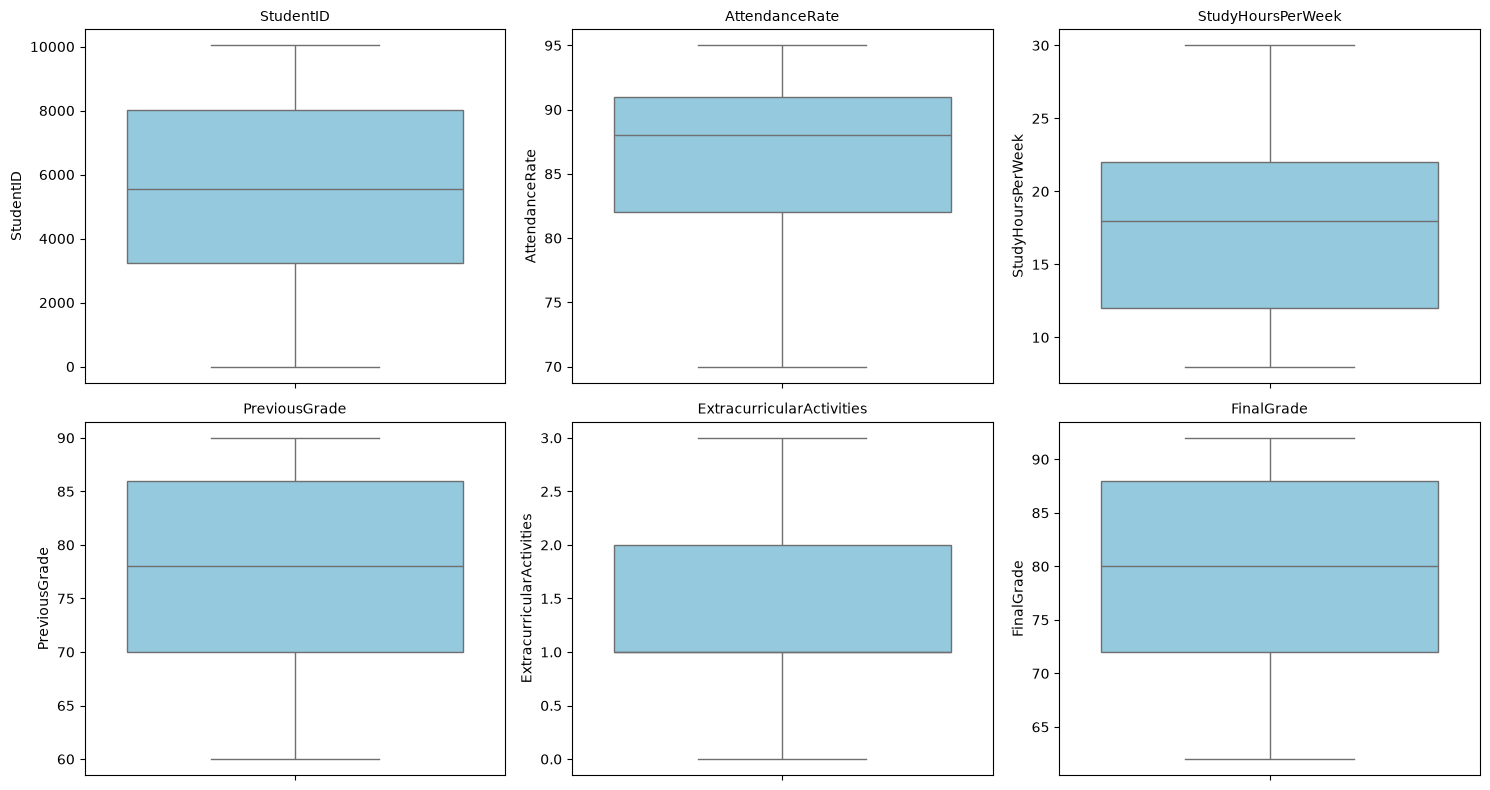

In [32]:
import math

num_col = dff.select_dtypes(include = ["number"]).columns
col_n = 3
row_n = math.ceil(len(num_col) / col_n )
fig , axes = plt.subplots(row_n , col_n , figsize = (15, row_n *4))
axes = axes.flatten()

for i , col in enumerate(num_col) :
    sns.boxplot(y=dff[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [33]:
dff['AttendanceRate'] = dff['AttendanceRate'].fillna(dff['AttendanceRate'].mean())
dff['StudyHoursPerWeek'] = dff['StudyHoursPerWeek'].fillna(dff['StudyHoursPerWeek'].mean())
dff['PreviousGrade'] = dff['PreviousGrade'].fillna(dff['PreviousGrade'].mean())
dff['ExtracurricularActivities'] = dff['ExtracurricularActivities'].fillna(dff['ExtracurricularActivities'].mean())
dff['FinalGrade'] = dff['FinalGrade'].fillna(dff['FinalGrade'].mean())

In [34]:
dff['ParentalSupport'] = dff['ParentalSupport'].fillna(dff['ParentalSupport'].mode()[0])
dff['Online Classes Taken'] = dff['Online Classes Taken'].fillna(dff['Online Classes Taken'].mode()[0])

In [35]:
dff.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  1000 non-null   float64
 1   Name                       1000 non-null   str    
 2   Gender                     1000 non-null   str    
 3   AttendanceRate             1000 non-null   float64
 4   StudyHoursPerWeek          1000 non-null   float64
 5   PreviousGrade              1000 non-null   float64
 6   ExtracurricularActivities  1000 non-null   float64
 7   ParentalSupport            1000 non-null   str    
 8   FinalGrade                 1000 non-null   float64
 9   Online Classes Taken       1000 non-null   object 
dtypes: float64(6), object(1), str(3)
memory usage: 78.3+ KB


# Predict

In [36]:
dff['study_hours_per_day'] = dff["StudyHoursPerWeek"]/7
dff

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Online Classes Taken,study_hours_per_day
0,1.0,John,Male,85.000000,15.000000,78.000000,1.0,High,80.000000,False,2.142857
1,2.0,Sarah,Female,90.000000,20.000000,85.000000,2.0,Medium,87.000000,True,2.857143
2,3.0,Alex,Male,78.000000,10.000000,65.000000,0.0,Low,68.000000,False,1.428571
3,4.0,Michael,Male,92.000000,25.000000,90.000000,3.0,High,92.000000,False,3.571429
4,5.0,Emma,Female,85.510417,18.000000,82.000000,2.0,Medium,85.000000,True,2.571429
...,...,...,...,...,...,...,...,...,...,...,...
995,10038.0,Kenneth Murray,Male,85.000000,20.000000,77.598759,1.0,High,72.000000,True,2.857143
996,4497.0,Amy Stout,Female,91.000000,17.630526,86.000000,0.0,High,90.000000,True,2.518647
997,1886.0,Unknown,Male,85.000000,8.000000,82.000000,2.0,Low,68.000000,False,1.142857
998,7636.0,Joseph Sherman,Male,88.000000,17.000000,60.000000,2.0,High,85.000000,True,2.428571


In [37]:
print(df['study_hours_per_day'].max())
print(df['study_hours_per_day'].min())

9.848749999999999
0.0


In [38]:
print(dff['study_hours_per_day'].max())
print(dff['study_hours_per_day'].min())

4.285714285714286
1.1428571428571428


In [39]:
bins = np.linspace(0, 10, 11)

df["hour_group"] = pd.cut(df["study_hours_per_day"], bins=bins)
lookup_table = df.groupby("hour_group")["final_exam_score"].mean()

dff["hour_group"] = pd.cut(dff["study_hours_per_day"], bins=bins)
dff["predicted_final_exam_score(The Standard is first data)"] = dff["hour_group"].map(lookup_table).astype(float)

df.drop(columns=["hour_group"], inplace=True)
dff.drop(columns=["hour_group"], inplace=True)

In [40]:
dff

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Online Classes Taken,study_hours_per_day,predicted_final_exam_score(The Standard is first data)
0,1.0,John,Male,85.000000,15.000000,78.000000,1.0,High,80.000000,False,2.142857,63.818194
1,2.0,Sarah,Female,90.000000,20.000000,85.000000,2.0,Medium,87.000000,True,2.857143,63.818194
2,3.0,Alex,Male,78.000000,10.000000,65.000000,0.0,Low,68.000000,False,1.428571,58.200115
3,4.0,Michael,Male,92.000000,25.000000,90.000000,3.0,High,92.000000,False,3.571429,78.492316
4,5.0,Emma,Female,85.510417,18.000000,82.000000,2.0,Medium,85.000000,True,2.571429,63.818194
...,...,...,...,...,...,...,...,...,...,...,...,...
995,10038.0,Kenneth Murray,Male,85.000000,20.000000,77.598759,1.0,High,72.000000,True,2.857143,63.818194
996,4497.0,Amy Stout,Female,91.000000,17.630526,86.000000,0.0,High,90.000000,True,2.518647,63.818194
997,1886.0,Unknown,Male,85.000000,8.000000,82.000000,2.0,Low,68.000000,False,1.142857,58.200115
998,7636.0,Joseph Sherman,Male,88.000000,17.000000,60.000000,2.0,High,85.000000,True,2.428571,63.818194


In [41]:
dff.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   StudentID                                               1000 non-null   float64
 1   Name                                                    1000 non-null   str    
 2   Gender                                                  1000 non-null   str    
 3   AttendanceRate                                          1000 non-null   float64
 4   StudyHoursPerWeek                                       1000 non-null   float64
 5   PreviousGrade                                           1000 non-null   float64
 6   ExtracurricularActivities                               1000 non-null   float64
 7   ParentalSupport                                         1000 non-null   str    
 8   FinalGrade                                        

In [42]:
print(dff['predicted_final_exam_score(The Standard is first data)'].max())
print(dff['predicted_final_exam_score(The Standard is first data)'].min())
print(dff['predicted_final_exam_score(The Standard is first data)'].mean())


83.29352126941257
58.20011542497377
66.58971305669198


# Predict Final Grade on first data (المعيار هو الداتا الإصطناعية الثانية)

In [43]:
bins = np.linspace(0, 10, 11)

dff["hour_group"] = pd.cut(dff["study_hours_per_day"], bins=bins)
lookup_table = dff.groupby("hour_group")["FinalGrade"].mean()

df["hour_group"] = pd.cut(df["study_hours_per_day"], bins=bins)
df["predicted_final_Grade(The Standard is second data)"] = df["hour_group"].map(lookup_table).astype(float)

df.drop(columns=["hour_group"], inplace=True)
dff.drop(columns=["hour_group"], inplace=True)

In [44]:
df["predicted_final_Grade(The Standard is second data)"] = df["predicted_final_Grade(The Standard is second data)"].fillna("more than 92")

In [45]:
df.loc[df['study_hours_per_day'] == 0, "predicted_final_Grade(The Standard is second data)"] = 'Very bad grade'

In [46]:
df[df['study_hours_per_day'] == 0]["predicted_final_Grade(The Standard is second data)"]


3        Very bad grade
44       Very bad grade
46       Very bad grade
231      Very bad grade
358      Very bad grade
              ...      
14679    Very bad grade
14861    Very bad grade
14883    Very bad grade
14913    Very bad grade
14933    Very bad grade
Name: predicted_final_Grade(The Standard is second data), Length: 188, dtype: object

In [48]:
df

,student_id,age,gender,study_hours_per_day,smartphone_usage_hours,social_media_hours,gaming_hours,streaming_hours,sleep_hours,exercise_hours,class_attendance_percent,assignment_completion_percent,caffeine_intake_cups,mental_health_status,parent_education_level,internet_quality,motivation_level,final_exam_score,mental_health_encoded,predicted_final_Grade(The Standard is second data)
0,1,21,Female,3.01,0.26,1.77,0.26,1.71,5.32,0.70,64.87,74.11,2.0,Good,Masters,Average,6.32,82.70,2,80.006584
1,2,23,Female,5.84,8.02,3.30,0.96,0.00,5.99,1.99,85.38,80.68,3.0,Average,Masters,Poor,2.52,85.65,1,more than 92
2,3,20,Female,7.80,10.13,0.00,2.23,2.54,6.36,1.82,76.15,79.69,2.0,Good,HighSchool,Poor,3.98,88.14,2,more than 92
3,4,20,Female,0.00,1.15,1.32,4.19,0.27,7.86,0.18,84.41,79.07,0.0,Average,HighSchool,Average,4.77,54.81,1,Very bad grade
4,5,24,Male,7.23,1.39,2.21,4.67,2.75,7.88,0.28,81.13,65.40,3.5,Good,HighSchool,Average,8.77,84.34,2,more than 92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,22,Female,4.40,5.47,0.00,2.10,1.45,8.26,0.05,88.61,73.31,1.0,Poor,Masters,Average,6.06,66.39,0,82.0376
14996,14997,24,Male,6.21,11.89,3.98,3.92,3.83,7.07,0.00,80.00,73.04,0.0,Poor,Bachelors,Average,10.00,73.38,0,more than 92
14997,14998,21,Male,6.61,5.82,2.33,1.33,2.01,3.91,1.67,80.68,90.72,1.0,Poor,Bachelors,Average,10.00,98.00,0,more than 92
14998,14999,22,Female,3.67,4.58,2.51,4.54,3.80,8.35,1.67,81.76,48.75,1.0,Good,HighSchool,Average,6.22,68.07,2,80.006584
